In [ ]:
import dask
from dask.distributed import Client
from dask.distributed import SSHCluster
from dask.distributed import LocalCluster 
from dask.delayed import delayed
import dask.dataframe as dd 
import dask.array as da
import dask.bag as d
import graphviz

import pandas as pd
import numpy as np
import itertools
from time import time
import warnings
warnings.filterwarnings("ignore")

In [2]:
n_workers = 1
nthreads  = 1

cluster = SSHCluster(
    ["10.67.22.48", "10.67.22.48", "10.67.22.229", "10.67.22.45"],
    worker_options={"nthreads": nthreads, "n_workers": n_workers},
    scheduler_options={"port":0, "dashboard_address": ":0"},
    connect_options={
    "known_hosts": None,
    "client_keys": "cluster_key"})

client = Client(cluster, timeout='180s')

2025-08-07 15:04:18,275 - distributed.deploy.ssh - INFO - 2025-08-07 15:04:18,274 - distributed.http.proxy - INFO - To route to workers diagnostics web server please install jupyter-server-proxy: python -m pip install jupyter-server-proxy
2025-08-07 15:04:18,303 - distributed.deploy.ssh - INFO - 2025-08-07 15:04:18,302 - distributed.scheduler - INFO - State start
2025-08-07 15:04:18,304 - distributed.deploy.ssh - INFO - 2025-08-07 15:04:18,303 - distributed.diskutils - INFO - Found stale lock file and directory '/tmp/dask-scratch-space/worker-ek1iyy3f', purging
2025-08-07 15:04:18,306 - distributed.deploy.ssh - INFO - 2025-08-07 15:04:18,306 - distributed.scheduler - INFO -   Scheduler at:   tcp://10.67.22.48:36407
2025-08-07 15:04:19,424 - distributed.deploy.ssh - INFO - 2025-08-07 15:04:19,423 - distributed.nanny - INFO -         Start Nanny at: 'tcp://10.67.22.48:46719'
2025-08-07 15:04:19,642 - distributed.deploy.ssh - INFO - 2025-08-07 15:04:19,638 - distributed.nanny - INFO -    

In [3]:
client

<Client: 'tcp://10.67.22.48:36407' processes=3 threads=3, memory=5.83 GiB>

In [7]:
client.scheduler_info()['workers'].keys()

dict_keys(['tcp://10.67.22.229:33971', 'tcp://10.67.22.45:40447', 'tcp://10.67.22.48:46135'])

In [4]:
## >> xx selects rotates bits to the right by xx places

def bites_converter(block): 
    # organize in numpy arrays of 64 bits
    byte_array = np.frombuffer(block, dtype=np.uint64)
    
    # bit masking
    head = (byte_array >> 61) & 0x7         # select bits 61–63 (3 bits)
    fpga = (byte_array >> 58) & 0x7         # select bits 58–60 (3 bits)
    chan = (byte_array >> 49) & 0x1FF       # select bits 49–57 (9 bits)
    orbit = (byte_array >> 17) & 0xFFFFFFFF  # select bits 17–48 (32 bits)
    bx = (byte_array >> 5) & 0xFFF        # select bits 5–16 (12 bits)
    tdc = (byte_array >> 0) & 0x1F         # select bits 0–4 (5 bits)
    
    # we are only interested in data with head== 2 
    df = pd.DataFrame(
    {"FPGA": fpga[head==2],
    "CHAN": chan[head==2],
    "ORBIT": orbit[head==2],
    "BX": bx[head==2],
    "TDC": tdc[head==2]} )
    
    return(df)

In [5]:
def read_file(file):

    client_kwargs={
        "endpoint_url": "https://cloud-areapd.pd.infn.it:5210", "verify": False}

    # small is a small bytes object from the start of the first file (to infer format), block is a list of Dask delayed objects, representing chunks of bytes from a file
    small, blocks = dask.bytes.read_bytes(
            file,
            key="32b22133696b4aad9a2872435d392277",
            secret="d2111717321d4f7dbd6755b98e95e713",
            client_kwargs=client_kwargs)  
    
    dfs = [dask.delayed(bites_converter)(block[0]) for block in blocks] # apply converter to each block lazily (each block object is a tuple, so i selct [0])
    # converts a list of Dask delayed objects (chunks of a DataFrame) into a unique Dask DataFrame
    ddf = dd.from_delayed(dfs)
    return(ddf)

In [6]:
# This fuction:
# - filters events with a single scintillator hit per orbit (in order to be able to identify a unique t_0)
# - assigns the chamber number to each event
# - filters events with less than num_hits chamber hits per orbit 
# - calculates relative time between the chamber hits and the scintillator hits to determine the drift time

def first_processing(df,num_hits):
    
    # select scintillator hits
    scintillator = df[(df["FPGA"]==1) & (df["CHAN"]==128)].copy()
    scintillator = scintillator[["ORBIT", "BX", "TDC"]]
    scintillator["t_0"] = 25*(scintillator["ORBIT"]*3564 + scintillator["BX"] + scintillator["TDC"]/30)

    # count scintillator hits per ORBIT
    scint_counts = scintillator.groupby("ORBIT").size().to_frame("scint_hits").reset_index()
    # keep only ORBITs with a single scintillator hit
    valid_orbits = scint_counts[scint_counts["scint_hits"] == 1]["ORBIT"]
    
 
    df = df[df["CHAN"]<=127] # remove info about the scintillator

    # assign chamber number
    df = df.assign(CHAMBER = -1)
    df["CHAMBER"] = df["CHAMBER"].mask((df["FPGA"] == 0) & (df["CHAN"] <= 63), 0)
    df["CHAMBER"] = df["CHAMBER"].mask((df["FPGA"] == 0) & (df["CHAN"] > 63), 1)
    df["CHAMBER"] = df["CHAMBER"].mask((df["FPGA"] == 1) & (df["CHAN"] <= 63), 2)
    df["CHAMBER"] = df["CHAMBER"].mask((df["FPGA"] == 1) & (df["CHAN"] > 63), 3)

    # scintilattor time offset correction, per chamber
    df = df.assign(time_offset = 0.0)
    df["time_offset"] = df["time_offset"].mask(df["CHAMBER"] == 0, 95.0-1.1)
    df["time_offset"] = df["time_offset"].mask(df["CHAMBER"] == 1, 95.0+6.4)
    df["time_offset"] = df["time_offset"].mask(df["CHAMBER"] == 2, 95.0+0.5)
    df["time_offset"] = df["time_offset"].mask(df["CHAMBER"] == 3, 95.0-2.6)
    
    df["T_HIT"] = 25*(df["ORBIT"]*3564 + df["BX"] + df["TDC"]/30)
    
    # filter scintillator hits and main df: keep only events with 1 scintillator hit per ORBIT
    scintillator = scintillator[scintillator["ORBIT"].isin(valid_orbits)]
    df = df[df["ORBIT"].isin(valid_orbits)]

    # consider only events with ≤ num_hits chamber hits per ORBIT (avoid overcrowded events)
    chamber_counts = df.groupby("ORBIT").size().to_frame("hits_count").reset_index()
    valid_orbits = chamber_counts[chamber_counts["hits_count"]<=num_hits][["ORBIT"]]
    df = df[df["ORBIT"].isin(valid_orbits["ORBIT"])]

    t0_df = scintillator[["ORBIT", "t_0"]]  # only 1 scint hit per ORBIT guaranteed here
   
    # merge t₀_df with df
    df = df.merge(t0_df, on="ORBIT", how="left") 
    
    # calculate relative chamber hit times
    df["T_REL"] = df["T_HIT"] - (df["t_0"]-df["time_offset"])
    
    return(df)    

In [17]:
# compute x and z coordinates of the chamber hits (left and right ambiguity for the x coordinate in each hit)

def compute_coordinates(df):
    
    df["x"]=-7.5*42.0 # center of the first cell to the left in each chamber
    df["z"]=0

    # assign the z-position of the center of each chamber wrt to the floor
    df["z"]=df["z"].mask(df["CHAMBER"]==0,219.8)
    df["z"]=df["z"].mask(df["CHAMBER"]==1,977.3)
    df["z"]=df["z"].mask(df["CHAMBER"]==2,1035.6)
    df["z"]=df["z"].mask(df["CHAMBER"]==3,1819.8)

    df["CHAN_LOCAL"] = df["CHAN"]
    df["CHAN_LOCAL"] = df["CHAN_LOCAL"].mask(df["CHAMBER"].isin([1,3]), df["CHAN"]- 64) 

    layer_map = [3, 1, 2, 0]
    df["layer"] = df["CHAN_LOCAL"]%4
    df["layer"] = df["layer"].map({i: layer_map[i] for i in range(4)})

    df["x"]= df["x"] + df["CHAN_LOCAL"]// 2 * 21.
    df["z"]= df["z"] - 26.0 + (df["layer"]+0.5)*13.

    df["drift"]= df["T_REL"]*53.8*0.001
    df = df[(df["drift"]>=0)&(df["drift"]<=21.)] # drift can be at most half of the cell, discard other events (meaningless)
    
    df["X_RIGHT"]= df["x"]+df["drift"] 
    df["X_LEFT"]= df["x"]-df["drift"]

    return(df)

In [18]:
df = read_file("s3://project-bkp/data_00000*") # use all files

In [9]:
df.npartitions

10

In [10]:
df.map_partitions(len).compute() # number of rows in each partition

0    1239940
0    1243176
0    1243816
0    1243252
0    1242676
0    1242348
0    1243244
0    1241716
0    1243108
0    1244404
dtype: int64

In [19]:
df = first_processing(df,25)

/home/ubuntu/.local/lib/python3.10/site-packages/dask/dataframe/dask_expr/_collection.py:4215: UserWarning: 
You did not provide metadata, so Dask is running your function on a small dataset to guess output types. It is possible that Dask will guess incorrectly.
To provide an explicit output types or to silence this message, please provide the `meta=` keyword, as described in the map function that you are using.
  Before: .map(func)
  After:  .map(func, meta=('layer', 'int64'))

  warnings.warn(meta_warning(meta, method="map"))


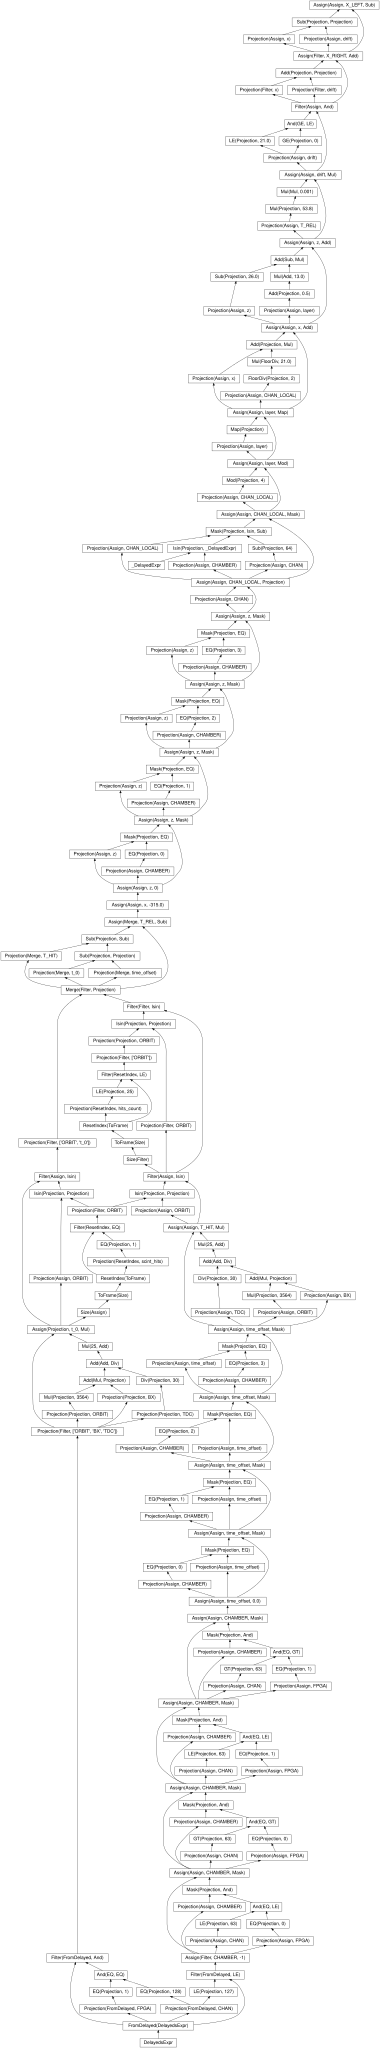

In [20]:
new_df = compute_coordinates(df)
new_df.visualize()

In [21]:
%%time
new_df.compute()

CPU times: user 506 ms, sys: 18.2 ms, total: 524 ms
Wall time: 12.5 s


,FPGA,CHAN,ORBIT,BX,TDC,CHAMBER,time_offset,T_HIT,t_0,T_REL,x,z,CHAN_LOCAL,layer,drift,X_RIGHT,X_LEFT
0,0,108,1144838,528,27,1,101.4,1.020051e+11,1.020051e+11,43.066666,147.0,996.8,44,3,2.316987,149.316987,144.683013
1,1,42,1144838,529,28,2,95.5,1.020051e+11,1.020051e+11,63.000000,126.0,1042.1,42,2,3.389400,129.389400,122.610600
2,1,110,1144838,528,8,3,92.4,1.020051e+11,1.020051e+11,18.233337,168.0,1826.3,46,2,0.980954,168.980954,167.019046
3,1,43,1144838,529,5,2,95.5,1.020051e+11,1.020051e+11,43.833328,126.0,1016.1,43,0,2.358233,128.358233,123.641767
4,1,111,1144838,529,6,3,92.4,1.020051e+11,1.020051e+11,41.566666,168.0,1800.3,47,0,2.236287,170.236287,165.763713
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7741,1,43,48576415,862,14,2,95.5,4.328159e+12,4.328159e+12,316.333496,126.0,1016.1,43,0,17.018742,143.018742,108.981258
7742,0,101,48576415,862,21,1,101.4,4.328159e+12,4.328159e+12,328.066895,63.0,970.8,37,1,17.649999,80.649999,45.350001
7743,0,105,48576415,857,16,1,101.4,4.328159e+12,4.328159e+12,198.899414,105.0,970.8,41,1,10.700788,115.700788,94.299212
7744,0,102,48576415,861,30,1,101.4,4.328159e+12,4.328159e+12,310.566406,84.0,983.8,38,2,16.708473,100.708473,67.291527


In [22]:
n_orbit = 8333222   
new_df[new_df['ORBIT']==n_orbit].compute()

,FPGA,CHAN,ORBIT,BX,TDC,CHAMBER,time_offset,T_HIT,t_0,T_REL,x,z,CHAN_LOCAL,layer,drift,X_RIGHT,X_LEFT
1262,1,46,8333222,2480,30,2,95.5,7.424901e+11,7.424901e+11,59.666626,168.0,1042.1,46,2,3.210064,171.210064,164.789936
1263,1,114,8333222,2485,20,3,92.4,7.424901e+11,7.424901e+11,173.233398,210.0,1826.3,50,2,9.319957,219.319957,200.680043
1264,1,47,8333222,2479,27,2,95.5,7.424901e+11,7.424901e+11,32.166626,168.0,1016.1,47,0,1.730564,169.730564,166.269436
1265,0,42,8333222,2481,5,0,93.9,7.424901e+11,7.424901e+11,62.233398,126.0,226.3,42,2,3.348157,129.348157,122.651843
1266,0,113,8333222,2483,1,1,101.4,7.424901e+11,7.424901e+11,116.400024,189.0,970.8,49,1,6.262321,195.262321,182.737679
1267,0,27,8333222,2487,25,0,93.9,7.424901e+11,7.424901e+11,228.899902,-42.0,200.3,27,0,12.314815,-29.685185,-54.314815
1268,0,115,8333222,2481,26,1,101.4,7.424901e+11,7.424901e+11,87.233276,210.0,957.8,51,0,4.693150,214.693150,205.306850
1269,0,30,8333222,2489,26,0,93.9,7.424901e+11,7.424901e+11,279.733276,0.0,226.3,30,2,15.049650,15.049650,-15.049650
1270,0,43,8333222,2482,6,0,93.9,7.424901e+11,7.424901e+11,88.066650,126.0,200.3,43,0,4.737986,130.737986,121.262014
1271,0,112,8333222,2485,9,1,101.4,7.424901e+11,7.424901e+11,173.066650,189.0,996.8,48,3,9.310986,198.310986,179.689014


In [ ]:
# persist results to continue
df = compute_coordinates(df).persist()

/home/ubuntu/.local/lib/python3.10/site-packages/dask/dataframe/dask_expr/_collection.py:4215: UserWarning: 
You did not provide metadata, so Dask is running your function on a small dataset to guess output types. It is possible that Dask will guess incorrectly.
To provide an explicit output types or to silence this message, please provide the `meta=` keyword, as described in the map function that you are using.
  Before: .map(func)
  After:  .map(func, meta=('layer', 'int64'))

  warnings.warn(meta_warning(meta, method="map"))


In [14]:
result= client.submit(add, x, y)

In [19]:
client.gather(result)

3

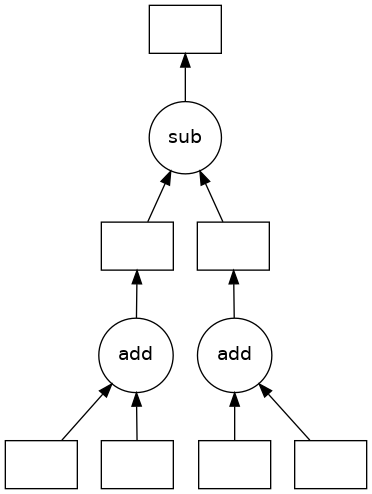

In [26]:
x= delayed(increment(2))
y=delayed(decrement(5))
z= delayed(add(x,y)) - delayed(add(delayed(decrement(8)),delayed(decrement(9))))
z.visualize()

In [ ]:
client.close()